In [17]:
from pathlib import Path
import numpy as np

MINERALS_DIR = Path(r"C:\Users\yudon\Downloads\usgs_splib07\ASCIIdata\ASCIIdata_splib07b\ChapterM_Minerals")

def read_usgs_spectrum_vector(path: Path, expected_len: int) -> np.ndarray:
    v = extract_numbers(path)
    # 欠損値が -1.23e34 の場合はここでNaN化したいなら追加で処理（必要なら）
    # v = np.where(v == -1.23e34, np.nan, v)
    # 明らかなヘッダ由来の巨大値を落とす（安全策）
    v = v[np.isfinite(v)]
    # 長さが合わなければ末尾を取る（USGSはデータが末尾に並ぶことが多い）
    if v.size >= expected_len:
        v = v[-expected_len:]
    if v.size != expected_len:
        raise ValueError(f"Length mismatch: {path.name} -> {v.size} (expected {expected_len})")
    return v.astype(float)


In [18]:
import numpy as np

# --- 1) 波長：350..2500 nm の厳密グリッドに固定（USGSファイル名に2151chとあるのでこれが正） ---
usgs_wave_nm_fixed = np.arange(350, 2501, 1, dtype=float)  # 350〜2500 inclusive => 2151本

print("Fixed USGS wavelength:", usgs_wave_nm_fixed.size,
      "range:", usgs_wave_nm_fixed.min(), "to", usgs_wave_nm_fixed.max(), "nm")

# --- 2) FWHM：読み込んだ usgs_fwhm_nm（現状0.0112 “nm” になってる配列）を単位判定して修正 ---
# 現状の usgs_fwhm_nm は「extract_numbers→フィルタ→末尾切り出し」した値だと思うので、
# まず長さを波長に合わせ、medianで単位判定します。

f = np.array(usgs_fwhm_nm, dtype=float).ravel()
f = f[np.isfinite(f)]
f = f[(f > 0) & (f < 200)]  # ヘッダ数字除去の安全弁

# 波長(2151)に合わせて末尾を採用
f = f[-usgs_wave_nm_fixed.size:]

# 単位判定：中央値が 1 未満なら「µmの可能性が高い」ので nmへ変換
if np.median(f) < 1.0:
    usgs_fwhm_nm_fixed = f * 1000.0   # µm -> nm
    unit = "µm -> nm"
else:
    usgs_fwhm_nm_fixed = f
    unit = "nm"

print("Fixed USGS FWHM:", usgs_fwhm_nm_fixed.size,
      "median:", float(np.median(usgs_fwhm_nm_fixed)), "nm",
      f"(interpreted as {unit})")

# 以後はこの2つを使う
usgs_wave_nm = usgs_wave_nm_fixed
usgs_fwhm_nm = usgs_fwhm_nm_fixed


Fixed USGS wavelength: 2151 range: 350.0 to 2500.0 nm
Fixed USGS FWHM: 2151 median: 11.2 nm (interpreted as µm -> nm)


In [ ]:
import numpy as np

usgs_wave_nm = np.arange(350, 2501, 1, dtype=float)  # 2151 bands

# FWHMは「HISUIの分光分解能」を使うのが本筋。
# 今は近似として一定値を使う（まず図を作る目的なら十分）
HISUI_FWHM_NM = 10.0

print("USGS wavelength fixed:", usgs_wave_nm.size, usgs_wave_nm.min(), usgs_wave_nm.max())
print("Using HISUI_FWHM_NM =", HISUI_FWHM_NM)


USGS wavelength fixed: 2151 350.0 2500.0
Using HISUI_FWHM_NM = 10.0


In [20]:
BAND_NM = (2100.0, 2500.0)
hisui_swir = hisui_wave_nm[(hisui_wave_nm >= BAND_NM[0]) & (hisui_wave_nm <= BAND_NM[1])]
print("HISUI SWIR bands:", hisui_swir.size, "range:", hisui_swir.min(), "to", hisui_swir.max())


HISUI SWIR bands: 31 range: 2100.055 to 2474.755


In [21]:
from pathlib import Path
import numpy as np
import math

USGS_BAD = -1.23e34

def read_usgs_spectrum_fixedlen(path: Path, expected_len: int) -> np.ndarray:
    """
    USGSの鉱物スペクトル txt から数値列を拾い、expected_lenに整形して返す。
    - ヘッダ由来の数値などで長くなっても、末尾 expected_len を採用
    - BAD値はNaN化
    """
    v = extract_numbers(path).astype(float)
    v = np.where(v == USGS_BAD, np.nan, v)
    v = v[np.isfinite(v)]
    # 多いときは末尾を使う（データが末尾に並ぶことが多い）
    if v.size >= expected_len:
        v = v[-expected_len:]
    if v.size != expected_len:
        raise ValueError(f"Length mismatch: {path.name} -> {v.size} (expected {expected_len})")
    return v

def pick_best_file_for_mineral(minerals_dir: Path, mineral: str, expected_len: int) -> Path:
    """
    mineral名を含む txt を全部候補にし、
    expected_lenに一致するものを優先して1つ選ぶ。
    """
    key = mineral.lower()
    hits = sorted([p for p in minerals_dir.rglob("*.txt") if key in p.name.lower()])
    if not hits:
        raise FileNotFoundError(f"No txt found for mineral='{mineral}' under {minerals_dir}")

    best = None
    best_score = (10**18, 10**18)  # (len mismatch, filename length)
    for p in hits:
        try:
            v = read_usgs_spectrum_fixedlen(p, expected_len)
            score = (0, len(p.name))  # 完全一致
        except Exception:
            # 長さだけ計測してスコア
            n = extract_numbers(p).size
            score = (abs(n - expected_len), len(p.name))
        if score < best_score:
            best_score = score
            best = p
    return best

def gaussian_project(src_wave_nm, src_spec, tgt_wave_nm, fwhm_nm: float):
    """ガウス装置関数（一定FWHM）で tgt 波長へ投影"""
    sigma = fwhm_nm / (2.0 * math.sqrt(2.0 * math.log(2.0)))
    out = np.full_like(tgt_wave_nm, np.nan, dtype=float)

    src_wave_nm = np.asarray(src_wave_nm, dtype=float)
    src_spec = np.asarray(src_spec, dtype=float)

    m = np.isfinite(src_wave_nm) & np.isfinite(src_spec)
    src_wave_nm = src_wave_nm[m]
    src_spec = src_spec[m]

    for i, lam in enumerate(tgt_wave_nm):
        left, right = lam - 4*sigma, lam + 4*sigma
        i0 = np.searchsorted(src_wave_nm, left, side="left")
        i1 = np.searchsorted(src_wave_nm, right, side="right")
        if i1 - i0 < 3:
            continue
        w = src_wave_nm[i0:i1]
        s = src_spec[i0:i1]
        mm = np.isfinite(w) & np.isfinite(s)
        if mm.sum() < 3:
            continue
        w, s = w[mm], s[mm]
        weights = np.exp(-0.5 * ((w - lam) / sigma) ** 2)
        out[i] = np.dot(weights, s) / weights.sum()
    return out


In [22]:
TARGET_MINERALS = [
    "Calcite",
    "Dolomite",
    "Kaolinite",
    "Montmorillonite",
    "Alunite",
    "Quartz",   # 対照
    "Muscovite",
]


Chosen files:
Calcite          -> splib07b_Calcite_WS272_BECKa_AREF.txt
Dolomite         -> splib07b_Dolomite_COD2005_BECKb_AREF.txt
Kaolinite        -> splib07b_Kaolinite_CM3_BECKa_AREF.txt
Montmorillonite  -> splib07b_Montmorillonite_CM20_BECKb_AREF.txt
Alunite          -> splib07b_Alunite_HS295_ASDFRa_AREF.txt
Quartz           -> splib07b_Quartz_HS32.4B_BECKa_AREF.txt
Muscovite        -> splib07b_Muscovite_IL107_BECKb_AREF.txt


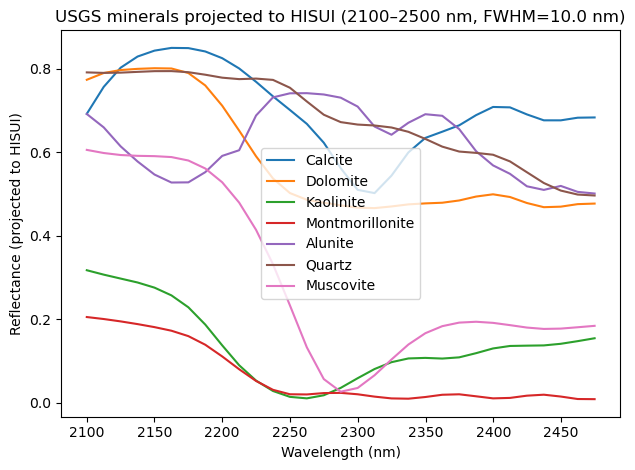

Saved figure: E:\tools\thesis\out_usgs_hisui\usgs_minerals_projected_to_hisui.png
Saved csv   : E:\tools\thesis\out_usgs_hisui\usgs_minerals_projected_to_hisui.csv


,wavelength_nm,Calcite,Dolomite,Kaolinite,Montmorillonite,Alunite,Quartz,Muscovite
0,2100.055,0.692116,0.773694,0.317283,0.205099,0.691688,0.791405,0.605679
1,2112.545,0.756724,0.789933,0.306718,0.200347,0.659646,0.790204,0.598191
2,2125.035,0.802662,0.797068,0.297283,0.194669,0.614120,0.790790,0.593392
3,2137.525,0.829398,0.799900,0.287890,0.188164,0.577901,0.792671,0.591435
4,2150.015,0.843562,0.801373,0.275571,0.180932,0.546598,0.794373,0.590687


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

OUTDIR = Path("./out_usgs_hisui")
OUTDIR.mkdir(exist_ok=True, parents=True)

chosen = {}
for m in TARGET_MINERALS:
    fp = pick_best_file_for_mineral(MINERALS_DIR, m, expected_len=usgs_wave_nm.size)
    chosen[m] = fp

print("Chosen files:")
for m, fp in chosen.items():
    print(f"{m:16s} -> {fp.name}")

# 出力テーブル
df = pd.DataFrame({"wavelength_nm": hisui_swir})

plt.figure()
for m, fp in chosen.items():
    spec = read_usgs_spectrum_fixedlen(fp, expected_len=usgs_wave_nm.size)

    # 2100-2500nmだけを元データ側も切る（高速化）
    mask = (usgs_wave_nm >= BAND_NM[0]-50) & (usgs_wave_nm <= BAND_NM[1]+50)
    w_b = usgs_wave_nm[mask]
    s_b = spec[mask]

    y = gaussian_project(w_b, s_b, hisui_swir, fwhm_nm=HISUI_FWHM_NM)
    df[m] = y
    plt.plot(hisui_swir, y, label=m)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance (projected to HISUI)")
plt.title(f"USGS minerals projected to HISUI (2100–2500 nm, FWHM={HISUI_FWHM_NM} nm)")
plt.legend()
plt.tight_layout()

fig_path = OUTDIR / "usgs_minerals_projected_to_hisui.png"
plt.savefig(fig_path, dpi=200)
plt.show()

csv_path = OUTDIR / "usgs_minerals_projected_to_hisui.csv"
df.to_csv(csv_path, index=False)

print("Saved figure:", fig_path.resolve())
print("Saved csv   :", csv_path.resolve())

df.head()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


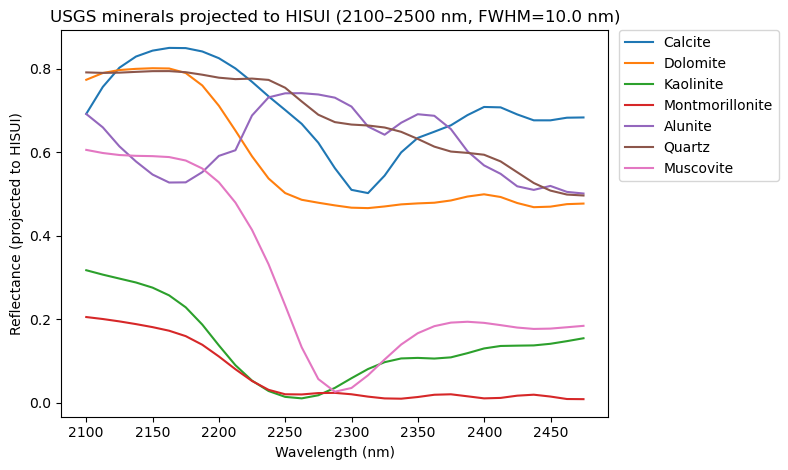

Saved figure: E:\tools\thesis\out_usgs_hisui\usgs_minerals_projected_to_hisui.eps


In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.8))

for m, fp in chosen.items():
    spec = read_usgs_spectrum_fixedlen(fp, expected_len=usgs_wave_nm.size)
    mask = (usgs_wave_nm >= BAND_NM[0]-50) & (usgs_wave_nm <= BAND_NM[1]+50)
    w_b = usgs_wave_nm[mask]
    s_b = spec[mask]
    y = gaussian_project(w_b, s_b, hisui_swir, fwhm_nm=HISUI_FWHM_NM)

    df[m] = y
    ax.plot(hisui_swir, y, label=m)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance (projected to HISUI)")
ax.set_title(f"USGS minerals projected to HISUI (2100–2500 nm, FWHM={HISUI_FWHM_NM} nm)")

# 凡例を右外へ
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0.0, frameon=True)

fig.tight_layout()

fig_path = OUTDIR / "usgs_minerals_projected_to_hisui.eps"
fig.savefig(fig_path,  bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path.resolve())


HISUI bands in range: 71 range: 1600.455 to 2474.755


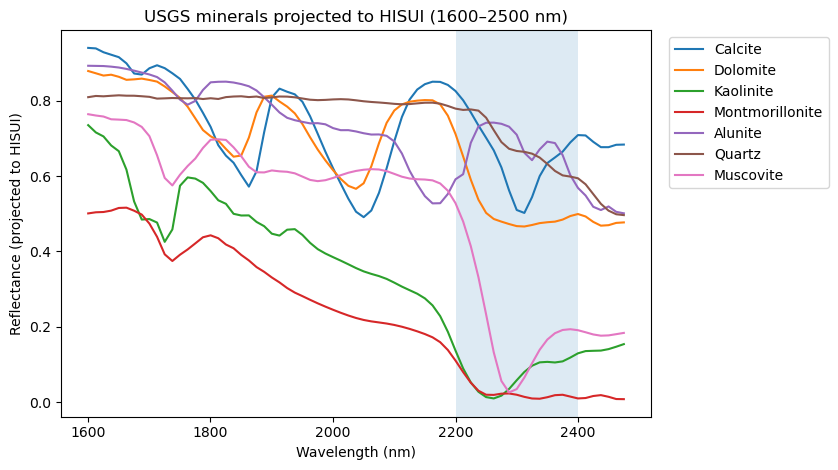

Saved: E:\tools\thesis\out_usgs_hisui\usgs_minerals_projected_to_hisui_1600_2500.png
Saved: E:\tools\thesis\out_usgs_hisui\usgs_minerals_projected_to_hisui_1600_2500.pdf
Saved: E:\tools\thesis\out_usgs_hisui\usgs_minerals_projected_to_hisui_1600_2500.csv
HISUI bands in range: 47 range: 1900.215 to 2474.755


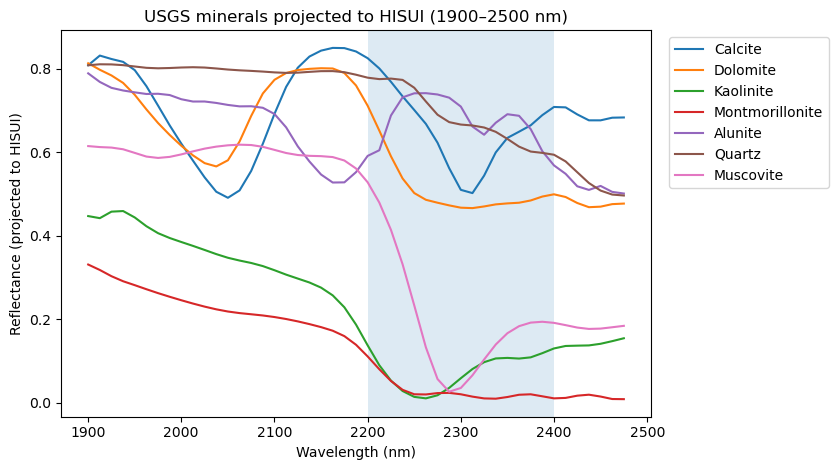

Saved: E:\tools\thesis\out_usgs_hisui\usgs_minerals_projected_to_hisui_1900_2500.png
Saved: E:\tools\thesis\out_usgs_hisui\usgs_minerals_projected_to_hisui_1900_2500.pdf
Saved: E:\tools\thesis\out_usgs_hisui\usgs_minerals_projected_to_hisui_1900_2500.csv


In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_projected_range(band_nm, filename_stem):
    lo, hi = band_nm
    hisui_band = hisui_wave_nm[(hisui_wave_nm >= lo) & (hisui_wave_nm <= hi)]
    print("HISUI bands in range:", hisui_band.size, "range:", hisui_band.min(), "to", hisui_band.max())

    df_wide = pd.DataFrame({"wavelength_nm": hisui_band})

    fig, ax = plt.subplots(figsize=(8.5, 4.8))

    for m, fp in chosen.items():
        spec = read_usgs_spectrum_fixedlen(fp, expected_len=usgs_wave_nm.size)

        # 元データ側も同程度に切り出し（高速化のため少し余裕を持たせる）
        mask = (usgs_wave_nm >= lo-80) & (usgs_wave_nm <= hi+80)
        w_b = usgs_wave_nm[mask]
        s_b = spec[mask]

        y = gaussian_project(w_b, s_b, hisui_band, fwhm_nm=HISUI_FWHM_NM)
        df_wide[m] = y
        ax.plot(hisui_band, y, label=m)

    # 2200–2400 nm を薄くハイライト（吸収帯の位置を強調）
    ax.axvspan(2200, 2400, alpha=0.15)

    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Reflectance (projected to HISUI)")
    ax.set_title(f"USGS minerals projected to HISUI ({lo:.0f}–{hi:.0f} nm)")

    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=True)
    fig.tight_layout()

    out_png = OUTDIR / f"{filename_stem}.png"
    out_pdf = OUTDIR / f"{filename_stem}.pdf"
    fig.savefig(out_png, dpi=200, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.show()

    out_csv = OUTDIR / f"{filename_stem}.csv"
    df_wide.to_csv(out_csv, index=False)
    print("Saved:", out_png.resolve())
    print("Saved:", out_pdf.resolve())
    print("Saved:", out_csv.resolve())

# 例1：1600–2500（おすすめ）
plot_projected_range((1600, 2500), "usgs_minerals_projected_to_hisui_1600_2500")

# 例2：1900–2500（よりSWIR2強調）
plot_projected_range((1900, 2500), "usgs_minerals_projected_to_hisui_1900_2500")


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


HISUI bands in range: 71 range: 1600.455 to 2474.755


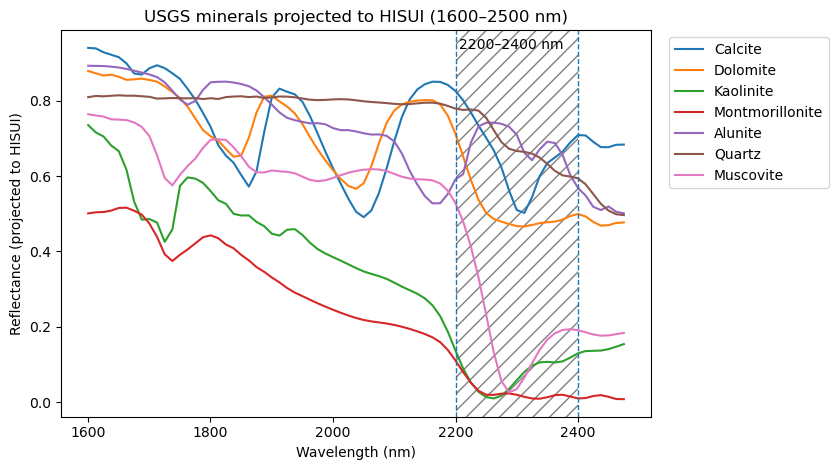

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved EPS: C:\b4_thesis_tex_example\thesisimg\usgs_minerals_projected_to_hisui_1600_2500.eps
Saved CSV: C:\b4_thesis_tex_example\thesisimg\usgs_minerals_projected_to_hisui_1600_2500.csv
HISUI bands in range: 47 range: 1900.215 to 2474.755


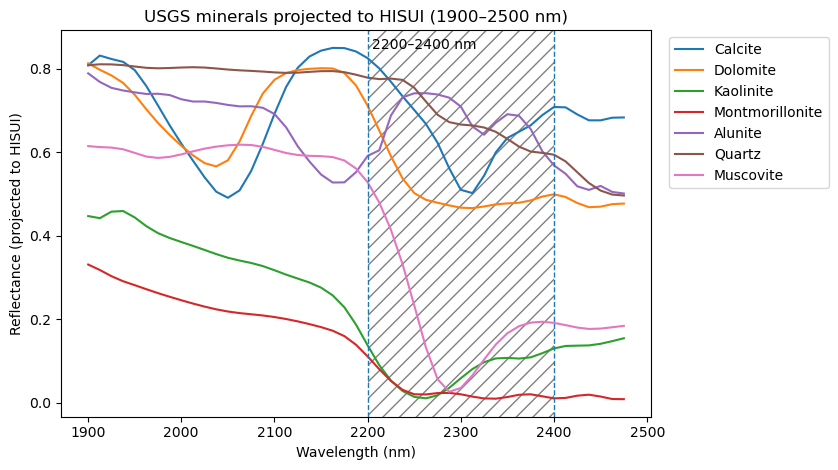

Saved EPS: C:\b4_thesis_tex_example\thesisimg\usgs_minerals_projected_to_hisui_1900_2500.eps
Saved CSV: C:\b4_thesis_tex_example\thesisimg\usgs_minerals_projected_to_hisui_1900_2500.csv


In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# epsを置きたい場所（あなたのLaTeXの thesisimg に合わせる）
OUT_EPS_DIR = Path(r"C:\b4_thesis_tex_example\thesisimg")
OUT_EPS_DIR.mkdir(parents=True, exist_ok=True)

def plot_projected_range_eps(band_nm, filename_stem):
    lo, hi = band_nm
    hisui_band = hisui_wave_nm[(hisui_wave_nm >= lo) & (hisui_wave_nm <= hi)]
    print("HISUI bands in range:", hisui_band.size, "range:", float(hisui_band.min()), "to", float(hisui_band.max()))

    df_wide = pd.DataFrame({"wavelength_nm": hisui_band})

    fig, ax = plt.subplots(figsize=(8.5, 4.8))

    for m, fp in chosen.items():
        spec = read_usgs_spectrum_fixedlen(fp, expected_len=usgs_wave_nm.size)

        # 元データ側も同程度に切る（高速化のため少し余裕）
        mask = (usgs_wave_nm >= lo-80) & (usgs_wave_nm <= hi+80)
        w_b = usgs_wave_nm[mask]
        s_b = spec[mask]

        y = gaussian_project(w_b, s_b, hisui_band, fwhm_nm=HISUI_FWHM_NM)
        df_wide[m] = y
        ax.plot(hisui_band, y, label=m)

    # --- 2200–2400 nm を「透過なし」で強調（EPS向け）---
    ax.axvspan(2200, 2400, facecolor="none", edgecolor="0.5", hatch="//", linewidth=0.0)
    ax.axvline(2200, linestyle="--", linewidth=1.0)
    ax.axvline(2400, linestyle="--", linewidth=1.0)
    ax.text(2205, ax.get_ylim()[1]*0.98, "2200–2400 nm", va="top")

    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Reflectance (projected to HISUI)")
    ax.set_title(f"USGS minerals projected to HISUI ({lo:.0f}–{hi:.0f} nm)")

    # 凡例は右外
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=True)
    fig.tight_layout()

    # 保存（EPS）
    out_eps = OUT_EPS_DIR / f"{filename_stem}.eps"
    fig.savefig(out_eps, format="eps", bbox_inches="tight")
    plt.show()

    # CSVも一緒に（必要なら）
    out_csv = OUT_EPS_DIR / f"{filename_stem}.csv"
    df_wide.to_csv(out_csv, index=False)

    print("Saved EPS:", out_eps)
    print("Saved CSV:", out_csv)

# 例：おすすめ2種類
plot_projected_range_eps((1600, 2500), "usgs_minerals_projected_to_hisui_1600_2500")
plot_projected_range_eps((1900, 2500), "usgs_minerals_projected_to_hisui_1900_2500")


In [29]:
import pandas as pd

f1 = r"E:\tools\thesis\16genkai\rmse_tables\rmse_SWIR-1_1612–1737_nm_SNR300_TRIALS100.csv"
f2 = r"E:\tools\thesis\16genkai\rmse_tables\rmse_SWIR-2_2262–2387_nm_SNR300_TRIALS100.csv"

df1 = pd.read_csv(f1)
df2 = pd.read_csv(f2)

print("SWIR-1 columns:", df1.columns.tolist())
print("SWIR-2 columns:", df2.columns.tolist())
display(df1.head())
display(df2.head())


SWIR-1 columns: ['True_Conc', 'mean', 'std', 'rmse', 'count']
SWIR-2 columns: ['True_Conc', 'mean', 'std', 'rmse', 'count']


,True_Conc,mean,std,rmse,count
0,1.8,-0.604721,4.503762,5.085231,98
1,5.0,3.738615,3.951783,4.128962,98
2,10.0,7.367659,5.609510,6.170205,97
3,15.0,12.646380,7.172719,7.514149,98
4,20.0,17.354788,7.600494,8.011314,99


,True_Conc,mean,std,rmse,count
0,1.8,1.771069,0.474699,0.473205,100
1,5.0,5.196207,1.814516,1.816050,100
2,10.0,9.228697,2.063194,2.192458,95
3,15.0,9.068656,3.907631,7.091980,99
4,20.0,19.281927,2.729584,2.809226,100


SWIR-1: x = True_Conc , y = rmse
SWIR-2: x = True_Conc , y = rmse


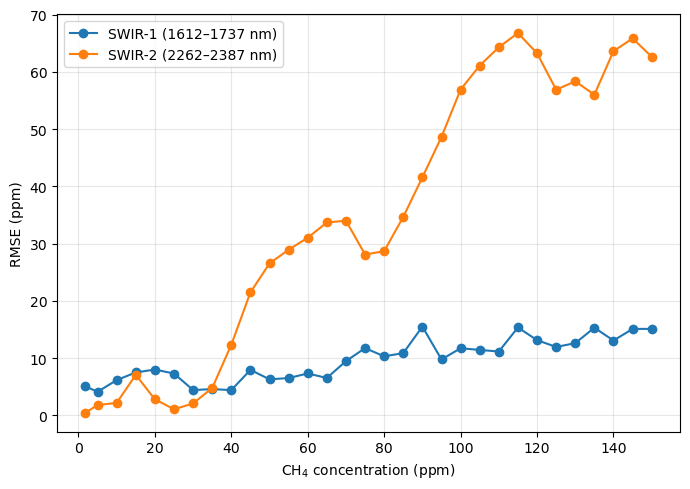

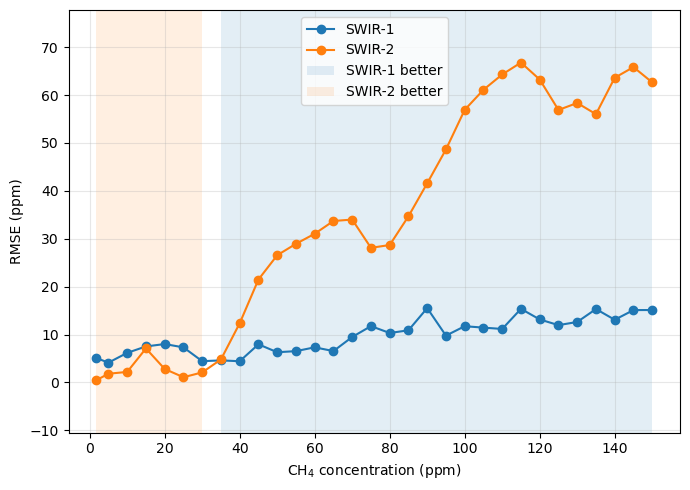

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

f1 = r"E:\tools\thesis\16genkai\rmse_tables\rmse_SWIR-1_1612–1737_nm_SNR300_TRIALS100.csv"
f2 = r"E:\tools\thesis\16genkai\rmse_tables\rmse_SWIR-2_2262–2387_nm_SNR300_TRIALS100.csv"

def pick_col(df, keywords, fallback="first_numeric"):
    cols = df.columns.tolist()
    low = [c.lower() for c in cols]
    for kw in keywords:
        for c, cl in zip(cols, low):
            if kw in cl:
                return c
    # fallback
    num_cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
    if not num_cols:
        raise ValueError("数値列が見つかりません。CSVの中身を確認してください。")
    if fallback == "first_numeric":
        return num_cols[0]
    if fallback == "last_numeric":
        return num_cols[-1]
    return num_cols[0]

def load_xy(path):
    df = pd.read_csv(path)
    xcol = pick_col(df, keywords=["true", "c_true", "ctrue", "concentration", "ppm", "target"], fallback="first_numeric")
    ycol = pick_col(df, keywords=["rmse"], fallback="last_numeric")
    out = df[[xcol, ycol]].copy()
    out.columns = ["x", "rmse"]
    out = out.dropna()
    out = out.sort_values("x")
    return out, xcol, ycol

d1, xcol1, ycol1 = load_xy(f1)
d2, xcol2, ycol2 = load_xy(f2)

print("SWIR-1: x =", xcol1, ", y =", ycol1)
print("SWIR-2: x =", xcol2, ", y =", ycol2)

# x の共通グリッド（同じ濃度が入っている前提が多いけど、違ってもマージで対応）
merged = pd.merge(d1, d2, on="x", how="outer", suffixes=("_s1", "_s2")).sort_values("x")

plt.figure(figsize=(7,5))
plt.plot(merged["x"], merged["rmse_s1"], marker="o", label="SWIR-1 (1612–1737 nm)")
plt.plot(merged["x"], merged["rmse_s2"], marker="o", label="SWIR-2 (2262–2387 nm)")
plt.xlabel("CH$_4$ concentration (ppm)")
plt.ylabel("RMSE (ppm)")
plt.grid(True, alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# どちらが優位かを塗り分け（任意）
plt.figure(figsize=(7,5))
plt.plot(merged["x"], merged["rmse_s1"], marker="o", label="SWIR-1")
plt.plot(merged["x"], merged["rmse_s2"], marker="o", label="SWIR-2")

# 優位領域（rmse_s1 < rmse_s2）を薄く塗る
m = merged.dropna(subset=["rmse_s1","rmse_s2"]).copy()
if len(m) >= 2:
    better_s1 = m["rmse_s1"] < m["rmse_s2"]
    # 連続区間を塗る（簡易版：点間を線形扱い）
    plt.fill_between(m["x"], 0, 1, where=better_s1, transform=plt.gca().get_xaxis_transform(), alpha=0.12, label="SWIR-1 better")
    plt.fill_between(m["x"], 0, 1, where=~better_s1, transform=plt.gca().get_xaxis_transform(), alpha=0.12, label="SWIR-2 better")

plt.xlabel("CH$_4$ concentration (ppm)")
plt.ylabel("RMSE (ppm)")
plt.grid(True, alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


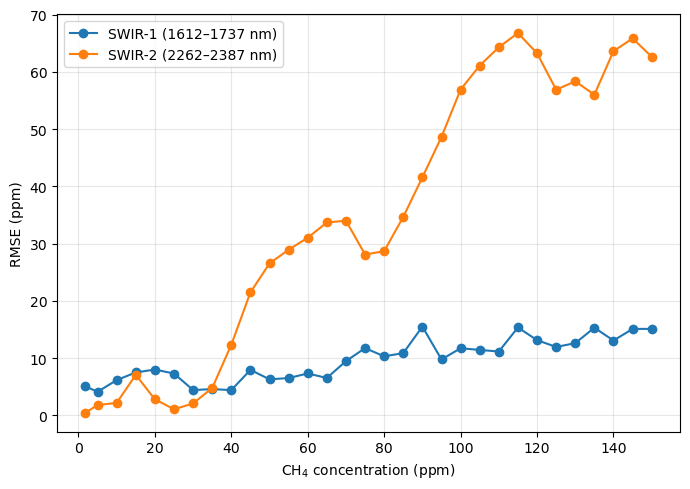

Saved: E:\tools\thesis\16genkai\rmse_tables\rmse_compare_swir1_swir2_300.eps


In [36]:
out_eps = r"E:\tools\thesis\16genkai\rmse_tables\rmse_compare_swir1_swir2_300.eps"

plt.figure(figsize=(7,5))
plt.plot(merged["x"], merged["rmse_s1"], marker="o", label="SWIR-1 (1612–1737 nm)")
plt.plot(merged["x"], merged["rmse_s2"], marker="o", label="SWIR-2 (2262–2387 nm)")
plt.xlabel("CH$_4$ concentration (ppm)")
plt.ylabel("RMSE (ppm)")
plt.grid(True, alpha=0.3)
plt.legend(loc="best")  # 邪魔なら loc="upper left" などに
plt.tight_layout()
plt.savefig(out_eps, format="eps", bbox_inches="tight", pad_inches=0)
plt.show()

print("Saved:", out_eps)


In [ ]:
out_eps = r"E:\tools\thesis\16genkai\rmse_tables\rmse_compare_swir1_swir2.eps"

plt.figure(figsize=(7,5))
plt.plot(merged["x"], merged["rmse_s1"], marker="o", label="SWIR-1 (1612–1737 nm)")
plt.plot(merged["x"], merged["rmse_s2"], marker="o", label="SWIR-2 (2262–2387 nm)")
plt.xlabel("CH$_4$ concentration (ppm)")
plt.ylabel("RMSE (ppm)")
plt.grid(True, alpha=0.3)
plt.legend(loc="best")  # 邪魔なら loc="upper left" などに
plt.tight_layout()
plt.savefig(out_eps, format="eps", bbox_inches="tight", pad_inches=0)
plt.show()

print("Saved:", out_eps)